# Разбор Итогового Decision Run

Цель:
- Проверить, как `end-to-end` decision pipeline раскладывает объекты по `id / candidate_ood / ood / unknown`.
- Дать star-level answer: какой класс, какой подкласс, какая физика у объекта и почему он ушел в `id` или `unknown`.
- Явно показать, подключены ли `host/priority` в текущем clean contract, а если нет — не скрывать это.
- Зафиксировать, где нужен следующий calibration-pass по `quality_gate` или `priority`.

In [1]:
# Настройка: корень репозитория, sys.path и базовые визуальные настройки.
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists():
            return candidate
    raise RuntimeError('Не удалось определить корень репозитория из текущей рабочей директории.')


REPO_ROOT = find_repo_root(Path.cwd()).resolve()
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)

None

In [2]:
# Импортируем review-хелперы после добавления src в sys.path.
from exohost.reporting.final_decision_review import (
    build_decision_reason_frame,
    build_domain_distribution_frame,
    build_domain_quality_crosstab_frame,
    build_final_coarse_class_frame,
    build_final_decision_summary_frame,
    build_final_refinement_label_frame,
    build_high_priority_candidate_physics_frame,
    build_high_priority_coarse_class_frame,
    build_high_priority_component_summary_frame,
    build_high_priority_refinement_label_frame,
    build_high_priority_summary_frame,
    build_host_priority_status_frame,
    build_numeric_state_summary_frame,
    build_priority_by_coarse_class_frame,
    build_priority_component_quantiles_frame,
    build_priority_distribution_frame,
    build_priority_reason_frame,
    build_quality_distribution_frame,
    build_quality_reason_frame,
    build_refinement_distribution_frame,
    build_review_bucket_frame,
    build_star_result_preview_frame,
    build_top_priority_candidates_frame,
    load_final_decision_review_bundle,
)
from exohost.reporting.notebook_display import rename_frame_for_display
from exohost.reporting.notebook_labels import (
    BOOLEAN_LABELS,
    FINAL_DOMAIN_STATE_LABELS,
    FINAL_REFINEMENT_STATE_LABELS,
    NUMERIC_SIGNAL_LABELS,
    PRIORITY_COMPONENT_LABELS,
    PRIORITY_LABELS,
    QUALITY_STATE_LABELS,
)


## План

- Загружаем один `final decision` artifact run.
- Сначала смотрим верхнеуровневый summary и распределения `domain / quality / refinement`.
- Потом разбираем `decision reasons`, `quality reasons`, `review buckets` и статус `host/priority`.
- После этого смотрим star-level preview: accepted `id` объекты и review/unknown pool с физикой.
- Если run еще не собран, ноутбук должен завершаться мягко и не ломать исполнение.

In [3]:
# Конфигурация ноутбук.
FINAL_DECISION_RUN_DIR: Path | None = REPO_ROOT / 'artifacts/decisions/hierarchical_final_decision_2026_04_05_123111_055017'
TOP_PRIORITY_ROWS = 20
STAR_PREVIEW_ROWS = 20
REVIEW_PREVIEW_ROWS = 20
NUMERIC_REVIEW_COLUMNS = (
    'host_similarity_score',
    'parallax',
    'parallax_over_error',
    'ruwe',
    'phot_g_mean_mag',
)


In [4]:
# Загружаем final-decision bundle, если run_dir уже указан.
review_available = FINAL_DECISION_RUN_DIR is not None
bundle = None
summary_df = pd.DataFrame()
domain_distribution_df = pd.DataFrame()
quality_distribution_df = pd.DataFrame()
refinement_distribution_df = pd.DataFrame()
reason_distribution_df = pd.DataFrame()
quality_reason_df = pd.DataFrame()
review_bucket_df = pd.DataFrame()
priority_status_df = pd.DataFrame()
priority_distribution_df = pd.DataFrame()
priority_reason_df = pd.DataFrame()
priority_component_quantiles_df = pd.DataFrame()
priority_by_class_df = pd.DataFrame()
high_priority_summary_df = pd.DataFrame()
high_priority_coarse_class_df = pd.DataFrame()
high_priority_refinement_label_df = pd.DataFrame()
high_priority_component_summary_df = pd.DataFrame()
high_priority_candidate_physics_df = pd.DataFrame()
domain_quality_crosstab_df = pd.DataFrame()
coarse_class_df = pd.DataFrame()
refinement_label_df = pd.DataFrame()
top_priority_candidates_df = pd.DataFrame()
id_star_preview_df = pd.DataFrame()
unknown_star_preview_df = pd.DataFrame()
numeric_state_summary_df = pd.DataFrame()

if not review_available:
    display(
        pd.DataFrame(
            [
                {
                    'status': 'waiting_for_final_decision_artifacts',
                    'note': 'Укажи FINAL_DECISION_RUN_DIR после первого end-to-end decide run.',
                }
            ]
        )
    )
else:
    if FINAL_DECISION_RUN_DIR is None or not FINAL_DECISION_RUN_DIR.exists():
        raise FileNotFoundError(FINAL_DECISION_RUN_DIR)

    bundle = load_final_decision_review_bundle(FINAL_DECISION_RUN_DIR)
    summary_df = build_final_decision_summary_frame(bundle)
    domain_distribution_df = build_domain_distribution_frame(bundle)
    quality_distribution_df = build_quality_distribution_frame(bundle)
    refinement_distribution_df = build_refinement_distribution_frame(bundle)
    reason_distribution_df = build_decision_reason_frame(bundle, top_n=20)
    quality_reason_df = build_quality_reason_frame(bundle, top_n=20)
    review_bucket_df = build_review_bucket_frame(bundle, top_n=20)
    priority_status_df = build_host_priority_status_frame(bundle)
    priority_distribution_df = build_priority_distribution_frame(bundle)
    priority_reason_df = build_priority_reason_frame(bundle, top_n=20)
    priority_component_quantiles_df = build_priority_component_quantiles_frame(bundle)
    priority_by_class_df = build_priority_by_coarse_class_frame(bundle)
    high_priority_summary_df = build_high_priority_summary_frame(bundle)
    high_priority_coarse_class_df = build_high_priority_coarse_class_frame(bundle, top_n=10)
    high_priority_refinement_label_df = build_high_priority_refinement_label_frame(bundle, top_n=10)
    high_priority_component_summary_df = build_high_priority_component_summary_frame(bundle)
    high_priority_candidate_physics_df = build_high_priority_candidate_physics_frame(bundle, top_n=10)
    domain_quality_crosstab_df = build_domain_quality_crosstab_frame(bundle)
    coarse_class_df = build_final_coarse_class_frame(bundle, final_domain_state='id', top_n=20)
    refinement_label_df = build_final_refinement_label_frame(bundle, final_domain_state='id', top_n=20)
    top_priority_candidates_df = build_top_priority_candidates_frame(bundle, top_n=TOP_PRIORITY_ROWS)
    id_star_preview_df = build_star_result_preview_frame(bundle, final_domain_state='id', top_n=STAR_PREVIEW_ROWS)
    unknown_star_preview_df = build_star_result_preview_frame(bundle, final_domain_state='unknown', top_n=REVIEW_PREVIEW_ROWS)
    numeric_state_summary_df = build_numeric_state_summary_frame(
        bundle,
        group_column='final_domain_state',
        numeric_columns=NUMERIC_REVIEW_COLUMNS,
    )

    display(
        rename_frame_for_display(
            summary_df,
            column_mapping={
                'pipeline_name': 'Пайплайн',
                'n_rows_decision_input': 'Строк во входе decision',
                'n_rows_final_decision': 'Строк в итоговом decision',
                'n_rows_priority_input': 'Строк во входе priority',
                'n_rows_priority_ranking': 'Строк в ranking-output',
            },
        )
    )


,run_dir,Пайплайн,created_at_utc,n_rows_input,Строк в итоговом decision,Строк во входе priority,Строк в ranking-output,n_unique_source_id
0,hierarchical_final_decision_2026_04_05_123111_...,hierarchical_final_decision,2026-04-05T12:31:11.055017+00:00,402226,402226,183631,183631,402226


,Итоговое состояние домена,Число строк,Доля
0,Проверить,216491,0.538232
1,ID,183631,0.456537
2,OOD,2104,0.005231


,Итоговое состояние качества,Число строк,Доля
0,Допуск,185735,0.461768
1,Отклонено,159964,0.397697
2,Проверить,56527,0.140535


,Итоговое состояние уточнения,Число строк,Доля
0,Уточнение не запускалось,218596,0.543466
1,Уточнение принято,183630,0.456534


Итоговое состояние качества,Допуск,Отклонено,Проверить
Итоговое состояние домена,,,
ID,183631,0,0
OOD,2104,0,0
Проверить,0,159964,56527


,final_coarse_class,n_rows,share
0,F,55705,0.303353
1,K,43585,0.237351
2,G,30707,0.167221
3,A,25122,0.136807
4,M,14443,0.078652
5,B,14068,0.076610
6,O,1,0.000005


,final_refinement_label,n_rows,share
0,K0,26185,0.142596
1,G0,15410,0.083918
2,F5,15227,0.082922
3,F0,13870,0.075532
4,F8,13142,0.071567
5,M0,13107,0.071377
6,A0,11040,0.060121
7,G5,8873,0.048320
8,F2,6321,0.034422
9,A2,6074,0.033077


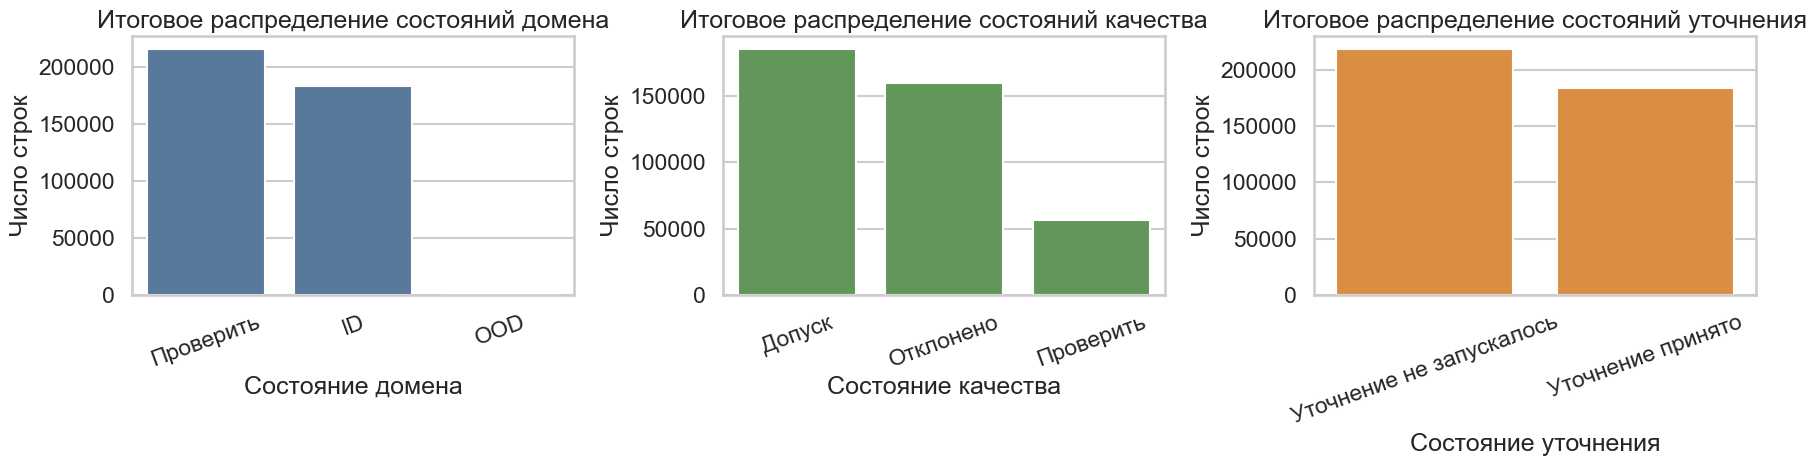

In [5]:
# Распределения domain / quality / refinement и баланс принятых классов и подклассов.
if review_available and bundle is not None:
    display(
        rename_frame_for_display(
            domain_distribution_df,
            column_mapping={'final_domain_state': 'Итоговое состояние домена', 'n_rows': 'Число строк', 'share': 'Доля'},
            value_mapping={'final_domain_state': FINAL_DOMAIN_STATE_LABELS},
        )
    )
    display(
        rename_frame_for_display(
            quality_distribution_df,
            column_mapping={'final_quality_state': 'Итоговое состояние качества', 'n_rows': 'Число строк', 'share': 'Доля'},
            value_mapping={'final_quality_state': QUALITY_STATE_LABELS},
        )
    )
    display(
        rename_frame_for_display(
            refinement_distribution_df,
            column_mapping={'final_refinement_state': 'Итоговое состояние уточнения', 'n_rows': 'Число строк', 'share': 'Доля'},
            value_mapping={'final_refinement_state': FINAL_REFINEMENT_STATE_LABELS},
        )
    )
    display(
        domain_quality_crosstab_df.rename(index=FINAL_DOMAIN_STATE_LABELS, columns=QUALITY_STATE_LABELS)
        .rename_axis(index='Итоговое состояние домена', columns='Итоговое состояние качества')
    )
    display(coarse_class_df)
    display(refinement_label_df)

    domain_plot_df = domain_distribution_df.copy()
    domain_plot_df['final_domain_state'] = domain_plot_df['final_domain_state'].map(
        lambda value: FINAL_DOMAIN_STATE_LABELS.get(str(value), str(value))
    )
    quality_plot_df = quality_distribution_df.copy()
    quality_plot_df['final_quality_state'] = quality_plot_df['final_quality_state'].map(
        lambda value: QUALITY_STATE_LABELS.get(str(value), str(value))
    )
    refinement_plot_df = refinement_distribution_df.copy()
    refinement_plot_df['final_refinement_state'] = refinement_plot_df['final_refinement_state'].map(
        lambda value: FINAL_REFINEMENT_STATE_LABELS.get(str(value), str(value))
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.barplot(data=domain_plot_df, x='final_domain_state', y='n_rows', ax=axes[0], color='#4C78A8')
    axes[0].set_title('Итоговое распределение состояний домена')
    axes[0].set_xlabel('Состояние домена')
    axes[0].set_ylabel('Число строк')
    axes[0].tick_params(axis='x', rotation=20)

    sns.barplot(data=quality_plot_df, x='final_quality_state', y='n_rows', ax=axes[1], color='#59A14F')
    axes[1].set_title('Итоговое распределение состояний качества')
    axes[1].set_xlabel('Состояние качества')
    axes[1].set_ylabel('Число строк')
    axes[1].tick_params(axis='x', rotation=20)

    sns.barplot(data=refinement_plot_df, x='final_refinement_state', y='n_rows', ax=axes[2], color='#F28E2B')
    axes[2].set_title('Итоговое распределение состояний уточнения')
    axes[2].set_xlabel('Состояние уточнения')
    axes[2].set_ylabel('Число строк')
    axes[2].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()


,Host-сигнал доступен,Строк во входе priority,Строк в ranking-output,Комментарий
0,Нет,183631,183631,Host/priority интеграция не подключена в текущ...


,Причина итогового решения,Число строк,Доля
0,refinement_accepted,183630,0.456534
1,quality_reject,159964,0.397697
2,quality_unknown,56527,0.140535
3,hard_ood,2104,0.005231
4,coarse_class_not_enabled,1,0.000002


,Причина quality_gate,Число строк,Доля
0,pass,185735,0.461768
1,missing_core_features,159964,0.397697
2,review_high_ruwe,41582,0.103380
3,review_low_parallax_snr,14945,0.037156


,Группа проверки,Число строк,Доля
0,pass,185735,0.461768
1,reject_missing_core_features,159873,0.397471
2,review_high_ruwe,41582,0.103380
3,review_low_parallax_snr,14945,0.037156
4,ood,91,0.000226


,Уровень приоритета,Число строк,Доля
0,Высокий,72113,0.392706
1,Низкий,69200,0.376843
2,Средний,42318,0.230451


...

,Строк в high-priority,Доля от priority-пула,Доля от ID-слоя,Медианный priority_score,Медианное сходство с host-профилем,Медианная наблюдаемость,Медианный SNR параллакса,Медианный RUWE,Медианная G-яркость
0,72113,0.392706,0.392706,0.877863,0.998,0.662852,222.9979,0.985974,9.436125


,Итоговый coarse-класс,Число строк,Доля
0,K,30114,0.417595
1,F,27488,0.381180
2,G,14341,0.198868
3,M,170,0.002357


,Итоговый подкласс,Число строк,Доля
0,K0,21283,0.295134
1,F5,9059,0.125622
2,G0,7229,0.100245
3,F8,6983,0.096834
4,F0,5352,0.074217
5,G5,5128,0.071111
6,K2,4392,0.060904
7,F2,3746,0.051946
8,K5,2245,0.031132
9,F3,1611,0.022340


,Показатель,P25,Медиана,P75
0,Итоговый priority_score,0.870249,0.877863,0.891720
1,Сходство с host-профилем,0.990202,0.998000,0.999429
2,Оценка наблюдаемости,0.643356,0.662852,0.706006
3,Приоритет спектрального класса,1.000000,1.000000,1.000000
4,Сигнал яркости,0.999957,1.000000,1.000000
5,Сигнал расстояния,0.007721,0.095875,0.205022
6,Астрометрический сигнал,0.935605,1.000000,1.000000
7,Температура GSP-Phot,4875.303000,5697.766600,6285.334500
8,logg GSP-Phot,2.656400,3.786900,4.126900
9,Металличность GSP-Phot,-0.385900,-0.189400,-0.050400


,source_id,Итоговый coarse-класс,Итоговый подкласс,priority_score,Причина приоритета,Сходство с host-профилем,Наблюдаемость,Приоритет класса,Сигнал яркости,Сигнал расстояния,Астрометрический сигнал,Температура GSP-Phot,logg GSP-Phot,Металличность GSP-Phot,Параллакс,SNR параллакса,RUWE,G-яркость,Радиус FLAME,Светимость FLAME
0,3618253627527608832,K,K0,0.999995,сильный host-like сигнал; хорошая наблюдательн...,0.999988,1.0,1.0,1.0,1.0,1.0,4910.3076,4.5109,-0.4796,26.347317,1440.8774,0.895767,8.864548,0.802462,0.337252
1,1638543767320133248,K,K5,0.999993,сильный host-like сигнал; хорошая наблюдательн...,0.999985,1.0,1.0,1.0,1.0,1.0,4982.6750,4.5044,0.2353,23.420393,1828.1552,0.894718,8.839774,0.873282,0.423557
2,708054946776797056,G,G8,0.999992,сильный host-like сигнал; хорошая наблюдательн...,0.999983,1.0,1.0,1.0,1.0,1.0,5319.4976,4.4625,0.0500,20.214529,1180.9241,0.916950,8.662633,0.936558,0.632737
3,5224357128908105728,G,G8,0.999992,сильный host-like сигнал; хорошая наблюдательн...,0.999982,1.0,1.0,1.0,1.0,1.0,5507.2144,4.4322,-0.0940,21.419786,1662.4296,0.874170,8.425118,0.914910,0.693746
4,2645536890392695424,K,K0,0.999991,сильный host-like сигнал; хорошая наблюдательн...,0.999979,1.0,1.0,1.0,1.0,1.0,4934.5420,4.5331,-0.0590,20.505608,1259.9688,0.922353,9.375323,0.800726,0.342512
5,4718719219080249344,G,G6,0.999989,сильный host-like сигнал; хорошая наблюдательн...,0.999975,1.0,1.0,1.0,1.0,1.0,5549.2627,4.4488,0.0912,22.179974,1397.9602,0.907715,8.232135,0.946212,0.765661
6,6739497724077399808,G,G8,0.999989,сильный host-like сигнал; хорошая наблюдательн...,0.999975,1.0,1.0,1.0,1.0,1.0,5349.2007,4.4723,-0.0470,20.071970,1074.5682,0.920979,8.824495,0.866009,0.553294
7,3120955444685055488,G,G8,0.999988,сильный host-like сигнал; хорошая наблюдательн...,0.999974,1.0,1.0,1.0,1.0,1.0,5496.9810,4.4364,-0.3264,22.789665,1265.4185,0.895012,8.245974,0.941182,0.728761
8,5725940142928541184,F,F8,0.999988,сильный host-like сигнал; хорошая наблюдательн...,0.999974,1.0,1.0,1.0,1.0,1.0,6097.2676,4.1967,-0.0388,21.009344,1159.8420,0.890734,7.122499,1.362167,2.310415
9,5562061542577445760,M,M3,0.999987,сильный host-like сигнал; хорошая наблюдательн...,0.999970,1.0,1.0,1.0,1.0,1.0,3885.6758,4.4589,-0.5003,39.127990,4284.0790,0.889137,9.489365,0.773801,0.122971


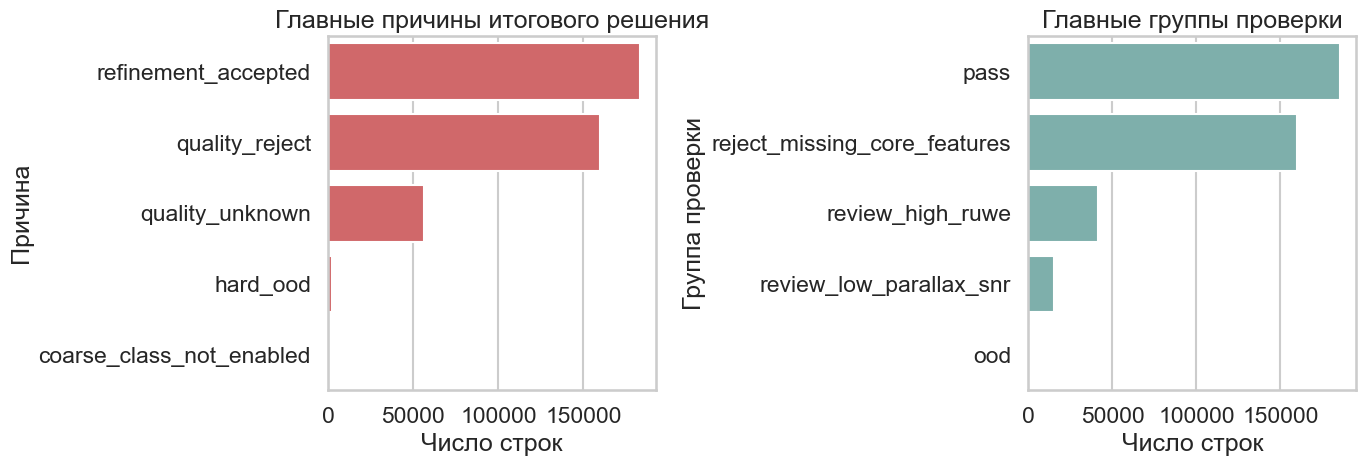

In [6]:
# Причины итоговых решений, группы review и явный статус host/priority.
if review_available and bundle is not None:
    display(
        rename_frame_for_display(
            priority_status_df,
            column_mapping={
                'host_signal_available': 'Host-сигнал доступен',
                'priority_input_rows': 'Строк во входе priority',
                'priority_output_rows': 'Строк в ranking-output',
                'status_note': 'Комментарий',
            },
            value_mapping={'host_signal_available': BOOLEAN_LABELS},
        )
    )
    display(
        rename_frame_for_display(
            reason_distribution_df,
            column_mapping={'final_decision_reason': 'Причина итогового решения', 'n_rows': 'Число строк', 'share': 'Доля'},
        )
    )
    display(
        rename_frame_for_display(
            quality_reason_df,
            column_mapping={'quality_reason': 'Причина quality_gate', 'n_rows': 'Число строк', 'share': 'Доля'},
        )
    )
    display(
        rename_frame_for_display(
            review_bucket_df,
            column_mapping={'review_bucket': 'Группа проверки', 'n_rows': 'Число строк', 'share': 'Доля'},
        )
    )

    if not priority_distribution_df.empty:
        display(
            rename_frame_for_display(
                priority_distribution_df,
                column_mapping={'priority_label': 'Уровень приоритета', 'n_rows': 'Число строк', 'share': 'Доля'},
                value_mapping={'priority_label': PRIORITY_LABELS},
            )
        )
        display(
            rename_frame_for_display(
                priority_reason_df,
                column_mapping={'priority_reason': 'Причина приоритета', 'n_rows': 'Число строк', 'share': 'Доля'},
            )
        )
        display(
            rename_frame_for_display(
                priority_component_quantiles_df,
                column_mapping={
                    'quantile': 'Квантиль',
                    'priority_score': PRIORITY_COMPONENT_LABELS['priority_score'],
                    'host_similarity_score': PRIORITY_COMPONENT_LABELS['host_similarity_score'],
                    'observability_score': PRIORITY_COMPONENT_LABELS['observability_score'],
                    'class_priority_score': PRIORITY_COMPONENT_LABELS['class_priority_score'],
                    'brightness_score': PRIORITY_COMPONENT_LABELS['brightness_score'],
                    'distance_score': PRIORITY_COMPONENT_LABELS['distance_score'],
                    'astrometry_score': PRIORITY_COMPONENT_LABELS['astrometry_score'],
                },
            )
        )
        display(
            rename_frame_for_display(
                priority_by_class_df,
                column_mapping={
                    'final_coarse_class': 'Итоговый coarse-класс',
                    'n_rows': 'Число строк',
                    'mean_priority_score': PRIORITY_COMPONENT_LABELS['mean_priority_score'],
                    'median_priority_score': PRIORITY_COMPONENT_LABELS['median_priority_score'],
                    'max_priority_score': PRIORITY_COMPONENT_LABELS['max_priority_score'],
                    'min_priority_score': PRIORITY_COMPONENT_LABELS['min_priority_score'],
                },
            )
        )
        display(
            rename_frame_for_display(
                high_priority_summary_df,
                column_mapping={
                    'n_rows': 'Строк в high-priority',
                    'share_priority_ranking': 'Доля от priority-пула',
                    'share_final_id': 'Доля от ID-слоя',
                    'median_priority_score': 'Медианный priority_score',
                    'median_host_similarity_score': 'Медианное сходство с host-профилем',
                    'median_observability_score': 'Медианная наблюдаемость',
                    'median_parallax_over_error': 'Медианный SNR параллакса',
                    'median_ruwe': 'Медианный RUWE',
                    'median_phot_g_mean_mag': 'Медианная G-яркость',
                },
            )
        )
        display(
            rename_frame_for_display(
                high_priority_coarse_class_df,
                column_mapping={
                    'final_coarse_class': 'Итоговый coarse-класс',
                    'n_rows': 'Число строк',
                    'share': 'Доля',
                },
            )
        )
        display(
            rename_frame_for_display(
                high_priority_refinement_label_df,
                column_mapping={
                    'final_refinement_label': 'Итоговый подкласс',
                    'n_rows': 'Число строк',
                    'share': 'Доля',
                },
            )
        )
        display(
            rename_frame_for_display(
                high_priority_component_summary_df,
                column_mapping={
                    'metric_name': 'Показатель',
                    'p25_value': 'P25',
                    'median_value': 'Медиана',
                    'p75_value': 'P75',
                },
                value_mapping={
                    'metric_name': {
                        **PRIORITY_COMPONENT_LABELS,
                        'teff_gspphot': 'Температура GSP-Phot',
                        'logg_gspphot': 'logg GSP-Phot',
                        'mh_gspphot': 'Металличность GSP-Phot',
                        'parallax': 'Параллакс',
                        'parallax_over_error': 'SNR параллакса',
                        'ruwe': 'RUWE',
                        'phot_g_mean_mag': 'G-яркость',
                        'radius_flame': 'Радиус FLAME',
                        'lum_flame': 'Светимость FLAME',
                    }
                },
            )
        )
        display(
            rename_frame_for_display(
                high_priority_candidate_physics_df,
                column_mapping={
                    'source_id': 'source_id',
                    'final_coarse_class': 'Итоговый coarse-класс',
                    'final_refinement_label': 'Итоговый подкласс',
                    'priority_score': 'priority_score',
                    'priority_reason': 'Причина приоритета',
                    'host_similarity_score': 'Сходство с host-профилем',
                    'observability_score': 'Наблюдаемость',
                    'class_priority_score': 'Приоритет класса',
                    'brightness_score': 'Сигнал яркости',
                    'distance_score': 'Сигнал расстояния',
                    'astrometry_score': 'Астрометрический сигнал',
                    'teff_gspphot': 'Температура GSP-Phot',
                    'logg_gspphot': 'logg GSP-Phot',
                    'mh_gspphot': 'Металличность GSP-Phot',
                    'parallax': 'Параллакс',
                    'parallax_over_error': 'SNR параллакса',
                    'ruwe': 'RUWE',
                    'phot_g_mean_mag': 'G-яркость',
                    'radius_flame': 'Радиус FLAME',
                    'lum_flame': 'Светимость FLAME',
                },
            )
        )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(data=reason_distribution_df.head(10), x='n_rows', y='final_decision_reason', ax=axes[0], color='#E15759')
    axes[0].set_title('Главные причины итогового решения')
    axes[0].set_xlabel('Число строк')
    axes[0].set_ylabel('Причина')

    sns.barplot(data=review_bucket_df.head(10), x='n_rows', y='review_bucket', ax=axes[1], color='#76B7B2')
    axes[1].set_title('Главные группы проверки')
    axes[1].set_xlabel('Число строк')
    axes[1].set_ylabel('Группа проверки')

    plt.tight_layout()
    plt.show()


=== Принятые объекты класса ID (предпросмотр) ===


,source_id,hostname,ra,dec,final_domain_state,final_quality_state,final_coarse_class,final_coarse_confidence,final_refinement_label,final_refinement_state,final_refinement_confidence,final_decision_reason,quality_reason,review_bucket,priority_score,priority_label,priority_reason,host_similarity_score,teff_gspphot,logg_gspphot,mh_gspphot,parallax,parallax_over_error,ruwe,phot_g_mean_mag,radius_flame,radius_gspphot,lum_flame,evolstage_flame
0,4047988225300671488,<NA>,275.782230,-29.860775,id,pass,K,0.999862,K8,accepted,1.0,refinement_accepted,pass,pass,NaN,<NA>,<NA>,<NA>,4794.3384,2.7092,0.0858,0.964983,66.026290,0.578644,11.135024,10.645297,NaN,53.675934,528.0
1,4048337187163081856,<NA>,278.856020,-28.963892,id,pass,K,0.999862,K8,accepted,1.0,refinement_accepted,pass,pass,NaN,<NA>,<NA>,<NA>,4859.9220,2.7157,-0.0019,1.036467,61.303017,0.730004,11.070233,10.652853,NaN,50.687300,535.0
2,2283441151289540864,<NA>,325.362950,76.386510,id,pass,M,0.999861,M3,accepted,1.0,refinement_accepted,pass,pass,NaN,<NA>,<NA>,<NA>,3456.2886,0.0363,0.5820,1.497749,21.626173,0.904133,9.357762,NaN,NaN,NaN,NaN
3,5843783634548236288,<NA>,195.220630,-70.962135,id,pass,M,0.999861,M3,accepted,1.0,refinement_accepted,pass,pass,NaN,<NA>,<NA>,<NA>,3555.8300,0.2983,0.6414,1.167377,17.460659,0.978394,9.592608,NaN,NaN,NaN,NaN
4,5531462511941104128,<NA>,119.050240,-44.142536,id,pass,M,0.999861,M3,accepted,1.0,refinement_accepted,pass,pass,NaN,<NA>,<NA>,<NA>,3408.5386,0.1348,0.5002,0.926405,15.022306,0.994051,9.794955,NaN,NaN,NaN,NaN
5,2069494463608443520,<NA>,308.825040,42.543877,id,pass,M,0.999861,M3,accepted,1.0,refinement_accepted,pass,pass,NaN,<NA>,<NA>,<NA>,3302.5970,-0.0037,0.7678,0.942148,14.662883,1.111455,11.800882,NaN,NaN,NaN,NaN
6,4169165234299694208,<NA>,265.443900,-6.461073,id,pass,M,0.999861,M0,accepted,1.0,refinement_accepted,pass,pass,NaN,<NA>,<NA>,<NA>,3466.8696,0.0880,0.3535,1.176588,12.957593,1.130273,9.418379,NaN,NaN,NaN,NaN
7,2073790672165713152,<NA>,297.889740,40.661095,id,pass,M,0.999861,M3,accepted,1.0,refinement_accepted,pass,pass,NaN,<NA>,<NA>,<NA>,3828.8586,0.3018,-0.2070,0.664913,12.645485,0.957658,10.544118,NaN,NaN,NaN,NaN
8,2019545166539767680,<NA>,292.793580,23.509369,id,pass,M,0.999861,M0,accepted,1.0,refinement_accepted,pass,pass,NaN,<NA>,<NA>,<NA>,3435.5344,-0.2342,0.2334,0.850119,11.728560,0.952084,10.481755,NaN,NaN,NaN,NaN
9,257302561472531456,<NA>,68.553246,47.259970,id,pass,M,0.999861,M3,accepted,1.0,refinement_accepted,pass,pass,NaN,<NA>,<NA>,<NA>,3406.7053,0.3259,-0.0400,1.091765,11.639637,1.236184,10.870188,NaN,NaN,NaN,NaN


=== Пул unknown / review (предпросмотр) ===


,source_id,hostname,ra,dec,final_domain_state,final_quality_state,final_coarse_class,final_coarse_confidence,final_refinement_label,final_refinement_state,final_refinement_confidence,final_decision_reason,quality_reason,review_bucket,priority_score,priority_label,priority_reason,host_similarity_score,teff_gspphot,logg_gspphot,mh_gspphot,parallax,parallax_over_error,ruwe,phot_g_mean_mag,radius_flame,radius_gspphot,lum_flame,evolstage_flame
0,4515331661278706432,<NA>,290.235400,18.885946,unknown,reject,NaN,NaN,NaN,not_attempted,NaN,quality_reject,missing_core_features,ood,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,1.923338,95.957504,0.917510,8.456932,NaN,NaN,NaN,NaN
1,6078883925202611968,<NA>,189.405460,-51.719910,unknown,reject,NaN,NaN,NaN,not_attempted,NaN,quality_reject,missing_core_features,ood,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,8.814673,88.113660,5.360483,11.676099,NaN,NaN,NaN,NaN
2,1998610190221148032,<NA>,353.462520,57.221043,unknown,reject,NaN,NaN,NaN,not_attempted,NaN,quality_reject,missing_core_features,ood,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,1.488808,86.106630,0.816312,8.284043,NaN,NaN,NaN,NaN
3,5403454619447879424,<NA>,168.061700,-32.433746,unknown,reject,NaN,NaN,NaN,not_attempted,NaN,quality_reject,missing_core_features,ood,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,3.631049,82.167710,1.067877,5.428725,NaN,NaN,NaN,NaN
4,5303085219480921600,<NA>,134.196350,-59.519978,unknown,reject,NaN,NaN,NaN,not_attempted,NaN,quality_reject,missing_core_features,ood,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,1.172279,74.375740,0.973766,9.050265,NaN,NaN,NaN,NaN
5,1041548574512696960,<NA>,127.798020,59.700750,unknown,reject,NaN,NaN,NaN,not_attempted,NaN,quality_reject,missing_core_features,ood,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,1.578723,64.995415,1.008978,8.201603,NaN,NaN,NaN,NaN
6,453735502094152832,<NA>,43.066490,55.709496,unknown,reject,NaN,NaN,NaN,not_attempted,NaN,quality_reject,missing_core_features,ood,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,0.662995,58.601150,0.986599,12.262678,NaN,NaN,NaN,NaN
7,38357979260707712,<NA>,58.711570,12.534890,unknown,reject,NaN,NaN,NaN,not_attempted,NaN,quality_reject,missing_core_features,ood,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,9.063227,57.910850,10.670566,12.515282,NaN,NaN,NaN,NaN
8,5525974849408587776,<NA>,126.259710,-44.184605,unknown,reject,NaN,NaN,NaN,not_attempted,NaN,quality_reject,missing_core_features,ood,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,0.696620,52.890614,0.970863,10.691083,NaN,NaN,NaN,NaN
9,5939663380639083264,<NA>,251.729740,-47.001440,unknown,reject,NaN,NaN,NaN,not_attempted,NaN,quality_reject,missing_core_features,ood,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,0.667048,47.843100,0.837811,12.056514,NaN,NaN,NaN,NaN


,Итоговое состояние,Показатель,Среднее значение,median_value,Число строк
0,ID,parallax,2.845993,2.106580,183631
1,OOD,parallax,0.647734,0.316841,2104
2,Проверить,parallax,1.909050,1.357521,210377
3,ID,SNR параллакса,162.614955,116.835464,183631
4,OOD,SNR параллакса,28.639671,13.422646,2104
5,Проверить,SNR параллакса,62.568115,43.613260,210377
6,ID,RUWE,1.010201,1.000312,183631
7,OOD,RUWE,1.015978,1.008447,2104
8,Проверить,RUWE,2.160552,1.076293,210377
9,ID,phot_g_mean_mag,11.128163,10.426659,183631


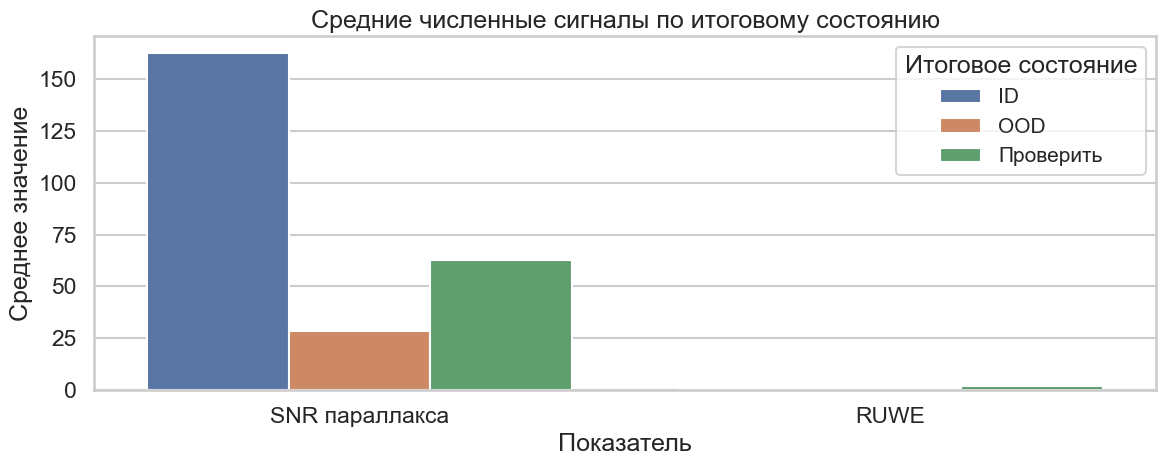

In [7]:
# Предпросмотр объектов и проверка физики/сигналов.
if review_available and bundle is not None:
    print('=== Принятые объекты класса ID (предпросмотр) ===')
    display(id_star_preview_df)

    print('=== Пул unknown / review (предпросмотр) ===')
    display(unknown_star_preview_df)

    display(
        rename_frame_for_display(
            numeric_state_summary_df,
            column_mapping={
                'group_value': 'Итоговое состояние',
                'metric_name': 'Показатель',
                'n_rows': 'Число строк',
                'mean_value': 'Среднее значение',
            },
            value_mapping={
                'group_value': FINAL_DOMAIN_STATE_LABELS,
                'metric_name': NUMERIC_SIGNAL_LABELS,
            },
        )
    )

    if not numeric_state_summary_df.empty:
        fig, ax = plt.subplots(figsize=(12, 5))
        plot_df = numeric_state_summary_df.loc[
            numeric_state_summary_df['metric_name'].isin(['host_similarity_score', 'ruwe', 'parallax_over_error'])
        ].copy()
        if not plot_df.empty:
            plot_df['metric_name'] = plot_df['metric_name'].map(
                lambda value: NUMERIC_SIGNAL_LABELS.get(str(value), str(value))
            )
            plot_df['group_value'] = plot_df['group_value'].map(
                lambda value: FINAL_DOMAIN_STATE_LABELS.get(str(value), str(value))
            )
            sns.barplot(data=plot_df, x='metric_name', y='mean_value', hue='group_value', ax=ax)
            ax.set_title('Средние численные сигналы по итоговому состоянию')
            ax.set_xlabel('Показатель')
            ax.set_ylabel('Среднее значение')
            ax.legend(title='Итоговое состояние', loc='best', fontsize='small')
            plt.tight_layout()
            plt.show()


## Опорные Источники

- [Jupyter Documentation](https://docs.jupyter.org/en/latest/)
- [scikit-learn: Probability calibration](https://scikit-learn.org/stable/modules/calibration.html)
- [scikit-learn: Tuning the decision threshold](https://scikit-learn.org/stable/modules/classification_threshold.html)
- [Gaia Archive use cases](https://www.cosmos.esa.int/web/gaia-users/archive/use-cases)

Этот ноутбук остается только review-слоем: вся воспроизводимая routing-логика живет в `src/exohost/posthoc` и `src/exohost/reporting`, а не внутри `.ipynb`.

## Следующие Шаги

- Если доля `unknown` выглядит слишком большой, сначала разбираем `quality_reason` и `review_bucket`, а не пытаемся сразу ослабить весь gate.
- Если top-zone по `priority` все еще слишком широкая, следующим шагом идет отдельный scaling review, а не хаотичное изменение ranking formula.
- Если `O`-класс по-прежнему исчезает на coarse-stage, это уже отдельная задача по rare-tail поведению модели.
- После стабилизации `quality_gate`, `priority` и coarse tail делаем новый сравнительный `end-to-end` run.